# Willowbend Creek: Coupled 2D Temperature Simulation

This notebook reproduces the model-output figures from the ClearWater-Riverine
Temperature technical report. It couples the ClearWater-Riverine 2D transport model
with the Temperature Simulation Module (TSM) from ClearWater-Modules on the
synthetic Willowbend Creek test case (2 km by 2 km, meandering channel with
an oxbow lake).

Inputs and a precomputed simulation output are bundled under
`docs/examples/data/willowbend_creek/`. The notebook can either re-run the
coupled model or load the precomputed output for figure generation.


## 1. Imports and paths

Run this notebook from the documentation repository root. The relative path
`docs/examples/data/willowbend_creek/` must resolve to the bundled test-case
directory.


/opt/homebrew/Caskroom/miniconda/base/envs/clearwater/lib/python3.13/site-packages/pyct/__init__.py:8: FutureWarning: param.version.Version has been deprecated and will be removed in a future version.
  __version__ = str(param.version.Version(fpath=__file__, archive_commit="$Format:%h$",
/opt/homebrew/Caskroom/miniconda/base/envs/clearwater/lib/python3.13/site-packages/param/version.py:200: FutureWarning: param.version.run_cmd has been deprecated and will be removed in a future version.
  remotes = run_cmd([cmd, 'remote', '-v'],


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
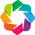

Figures will be written to: /Users/todd/GitHub/ecohydrology/Publication-ClearWater-Riverine-01-Temperature/notebooks/figures


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

import holoviews as hv

import clearwater_modules as cwm
from clearwater_modules.config import init_from_file
from clearwater_riverine.plotting import RiverinePlotter

hv.extension("bokeh")

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 9,
})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
print(f"Figures will be written to: {FIG_DIR.resolve()}")


In [ ]:
# Quiet ClearWater per-timestep logging and matplotlib font-cache chatter so the
# rendered notebook output stays focused on the figures themselves. Comment out
# the lines below if you want full diagnostics during a fresh run.
import logging

for name in ("clearwater_modules", "clearwater_riverine", "clearwater_data",
             "matplotlib", "matplotlib.font_manager", "PIL", "fiona", "rasterio"):
    logging.getLogger(name).setLevel(logging.WARNING)
logging.getLogger().setLevel(logging.WARNING)


## 2. Load configuration and run the coupled model

The coupled Riverine and TSM simulation is driven by `data/willowbend_creek/modules.yml`,
which references the HEC-RAS 2D plan HDF, the thermal boundary-condition
CSV, the meteorological CSVs, and the initial-condition CSV.


In [3]:
model_name = "willowbend_creek"
sim_path = Path.cwd() / "data" / model_name
config_path = sim_path / "modules.yml"
assert config_path.exists(), f"Configuration not found at {config_path}"

model = init_from_file(config_path)


In [4]:
%time model.run()


CPU times: user 1min 18s, sys: 3.36 s, total: 1min 22s
Wall time: 1min 21s


## 3. Access model output

The v2 model stores state and derived variables in a `VariableRegistry`
attached to the model instance. Retrieving a variable by name returns an
xarray DataArray dimensioned as `(time, nface)` for cell-centered variables
or `(time, nedge)` for edge-based variables.


In [5]:
registry = model._Model__registry

water_temperature = registry.get("water_temperature")
water_temperature_transport = registry.get("water_temperature_transport")
face_x = registry.get("face_x")
face_y = registry.get("face_y")
time_coord = water_temperature.time

_T_values = water_temperature.values  # (ntime, nface)

print("water_temperature dims:", dict(water_temperature.sizes))
print("time range:", time_coord.values[0], "to", time_coord.values[-1])
print("n_faces (total):", face_x.size)


water_temperature dims: {'time': 4321, 'nface': 444}
time range: 2022-05-13T08:00:00.000000000 to 2022-05-14T20:00:00.000000000
n_faces (total): 444


## 3b. Mesh polygon helpers

The HEC-RAS 2D unstructured mesh is rendered as filled polygons rather than
scatter points at face centroids. The helpers below build a list of cell
polygons once from `node_x`, `node_y`, and the `face_nodes` connectivity
array, and provide a reusable `plot_polygons` function that shades each cell
by a per-cell data value. Cells outside an optional wetness mask are drawn
in a muted grey to keep dry/inactive cells visible without confusing them
with low-value data. This matches the rendering style used in Publication 2
of this series.


In [6]:
DRY_FILL = (0.94, 0.94, 0.94, 1.0)
DRY_EDGE = (0.55, 0.55, 0.55, 1.0)
MESH_FILL = "#e8f1f8"
MESH_EDGE = "#2060a0"


def face_polygons(registry):
    # Return a list of (Nvert x 2) polygon vertex arrays, one per real cell,
    # plus the corresponding face index for each polygon. Cells whose
    # face_nodes row contains fewer than three valid node references are
    # skipped (this happens for ghost/padding rows in the HDF).
    nx = registry.get("node_x").values
    ny = registry.get("node_y").values
    face_nodes = registry.get("face_nodes").values
    n_nodes = len(nx)
    polys, face_ids = [], []
    for i in range(face_nodes.shape[0]):
        row = face_nodes[i]
        mask = np.isfinite(row) & (row >= 0) & (row < n_nodes)
        nodes = row[mask].astype(int)
        if len(nodes) < 3:
            continue
        polys.append(np.column_stack([nx[nodes], ny[nodes]]))
        face_ids.append(i)
    return polys, np.array(face_ids)


def plot_polygons(ax, polys, face_ids, values, *, cmap="viridis", norm=None,
                  vmin=None, vmax=None, mask=None,
                  show_edges=False, edgecolor="k", lw=0.2):
    # Shade each cell polygon by its per-face value. Cells where mask==False
    # are drawn with the dry/inactive style; wet cells are colored from the
    # colormap. Returns a ScalarMappable suitable for fig.colorbar().
    values = np.asarray(values).squeeze()
    if values.ndim > 1:
        values = values[..., 0]
    vals = values[face_ids]
    if mask is not None:
        mask_arr = np.asarray(mask).squeeze()
        if mask_arr.ndim > 1:
            mask_arr = mask_arr[..., 0]
        cell_mask = mask_arr[face_ids].astype(bool)
    else:
        cell_mask = np.ones(len(face_ids), dtype=bool)
    finite_vals = vals[cell_mask & np.isfinite(vals)]
    if norm is None:
        if vmin is None:
            vmin = float(np.nanmin(finite_vals)) if finite_vals.size else 0.0
        if vmax is None:
            vmax = float(np.nanmax(finite_vals)) if finite_vals.size else 1.0
        if vmin == vmax:
            vmax = vmin + max(1e-9, abs(vmin) * 1e-3)
        norm = Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    data_colors = cmap_obj(norm(np.clip(vals, norm.vmin, norm.vmax)))

    dry = [polys[i] for i in range(len(polys)) if not cell_mask[i]]
    if dry:
        ax.add_collection(PatchCollection(
            [MplPolygon(p, closed=True) for p in dry],
            facecolors=DRY_FILL, edgecolors="none",
        ))
    wet = [polys[i] for i in range(len(polys)) if cell_mask[i]]
    wet_colors = np.array([data_colors[i]
                           for i in range(len(polys)) if cell_mask[i]])
    if wet:
        ax.add_collection(PatchCollection(
            [MplPolygon(p, closed=True) for p in wet],
            facecolors=wet_colors,
            edgecolors="none",
        ))
    # Overlay consistent grid-cell outlines on top of the fills so the
    # mesh is visible over both wet and dry cells. Uses the dry-cell
    # outline color for a uniform look across every plot.
    outline_color = edgecolor if show_edges else DRY_EDGE
    outline_lw = lw if show_edges else 0.15
    ax.add_collection(PatchCollection(
        [MplPolygon(p, closed=True) for p in polys],
        facecolors="none", edgecolors=outline_color, linewidths=outline_lw,
        zorder=3,
    ))
    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    return sm


def set_common_axis(ax, face_x_da, face_y_da, pad=50):
    ax.set_aspect("equal")
    ax.set_xlim(float(face_x_da.min()) - pad, float(face_x_da.max()) + pad)
    ax.set_ylim(float(face_y_da.min()) - pad, float(face_y_da.max()) + pad)
    ax.set_xlabel("UTM Easting (m)")
    ax.set_ylabel("UTM Northing (m)")


polys, face_ids = face_polygons(registry)
print(f"Built {len(polys)} cell polygons from {registry.get('node_x').size} mesh nodes")


Built 367 cell polygons from 549 mesh nodes


## 4. Figure: Willowbend Creek domain

`fig:willowbend-domain` shows the computational mesh outline, the locations
of the four prescribed boundaries, and the oxbow lake feature. The mesh is
drawn from cell centroids read from the HEC-RAS 2D plan HDF via the
ClearWater-Riverine mesh loader.


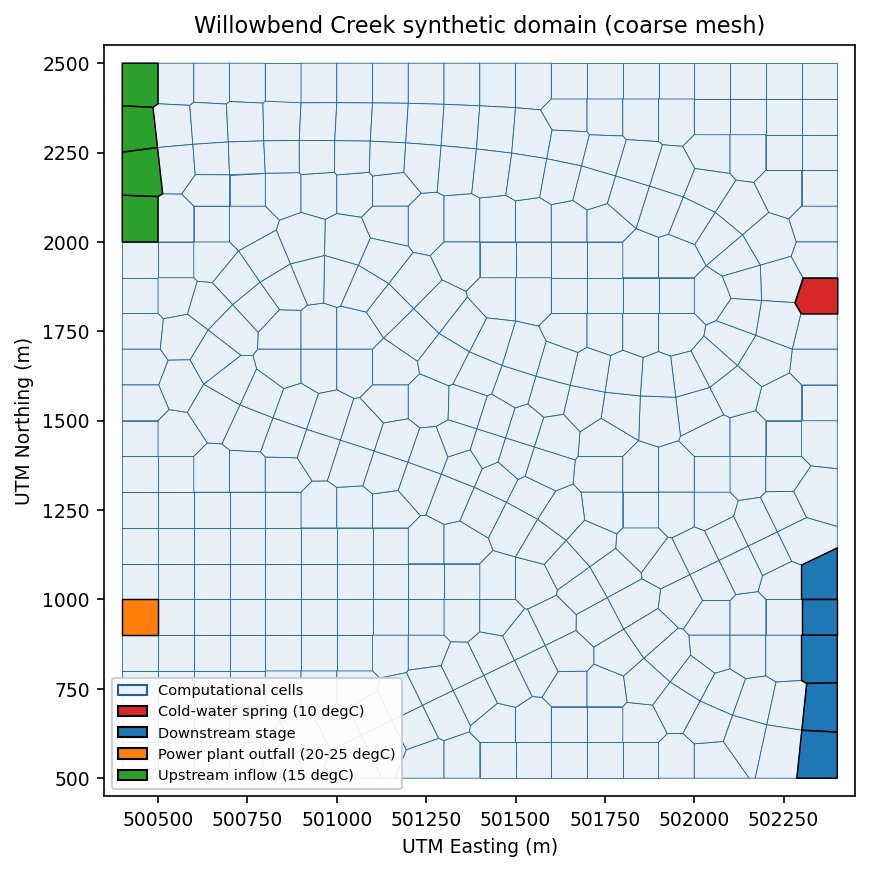

In [7]:
# Boundary-condition cell lookup. Registry exposes per-boundary-edge arrays
# "Name", "Face Index" (edge index in the HEC-RAS sense), and "BC Line ID".
# Each edge is resolved to an adjacent real cell via edge_face_connectivity.
LABEL_MAP = {
    "US_Flow": "Upstream inflow (15 degC)",
    "CoriolisColdSpringCreek": "Cold-water spring (10 degC)",
    "PwrPlnt_Flow": "Power plant outfall (20-25 degC)",
    "DS_Stage": "Downstream stage",
}


def _boundary_cells(registry) -> dict[str, list[int]]:
    try:
        names = registry.get("Name").values
        edge_idx = registry.get("Face Index").values.astype(int)
        efc = registry.get("edge_face_connectivity").values.astype(int)
    except (KeyError, ValueError):
        return {}
    nface = face_x.size
    out: dict[str, list[int]] = {}
    for name in np.unique(names):
        sel = (names == name)
        edges = edge_idx[sel]
        cs = []
        for e in edges:
            adj = efc[e]
            cand = [c for c in adj if 0 <= c < nface]
            if cand:
                cs.append(cand[0])
        if cs:
            out[str(name)] = sorted(set(cs))
    return out


fig, ax = plt.subplots(figsize=(7.0, 6.5))

# Base mesh: all cells as filled polygons with a distinct topology style.
ax.add_collection(PatchCollection(
    [MplPolygon(p, closed=True) for p in polys],
    facecolors=MESH_FILL, edgecolors=MESH_EDGE, linewidths=0.4,
))

# Highlight boundary-condition cells by recoloring those polygons.
bc_cells = _boundary_cells(registry)
bc_colors = ["#d62728", "#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#8c564b"]
legend_handles = [mpatches.Patch(facecolor=MESH_FILL, edgecolor=MESH_EDGE,
                                 label="Computational cells")]

face_id_to_poly = {int(fid): polys[k] for k, fid in enumerate(face_ids)}
for i, (raw_label, cs) in enumerate(bc_cells.items()):
    color = bc_colors[i % len(bc_colors)]
    friendly = LABEL_MAP.get(raw_label, raw_label)
    bc_polys = [face_id_to_poly[c] for c in cs if c in face_id_to_poly]
    if bc_polys:
        ax.add_collection(PatchCollection(
            [MplPolygon(p, closed=True) for p in bc_polys],
            facecolors=color, edgecolors="black", linewidths=0.7, zorder=4,
        ))
        legend_handles.append(mpatches.Patch(facecolor=color, edgecolor="black",
                                             label=friendly))

set_common_axis(ax, face_x, face_y)
ax.set_title("Willowbend Creek synthetic domain (computational mesh)")
ax.legend(handles=legend_handles, loc="lower left", fontsize=7, framealpha=0.9)

fig.savefig(FIG_DIR / "willowbend_domain.png")
plt.show()


## 5. Figure: Bathymetry

`fig:bathymetry` shows the per-cell minimum bed elevation (bathymetry) of
the Willowbend Creek mesh, read directly from the HEC-RAS 2D plan HDF via
the registry variable `lookup_elevation`. The viridis colormap highlights
the thalweg and floodplain topography that drives the hydrodynamic
response.


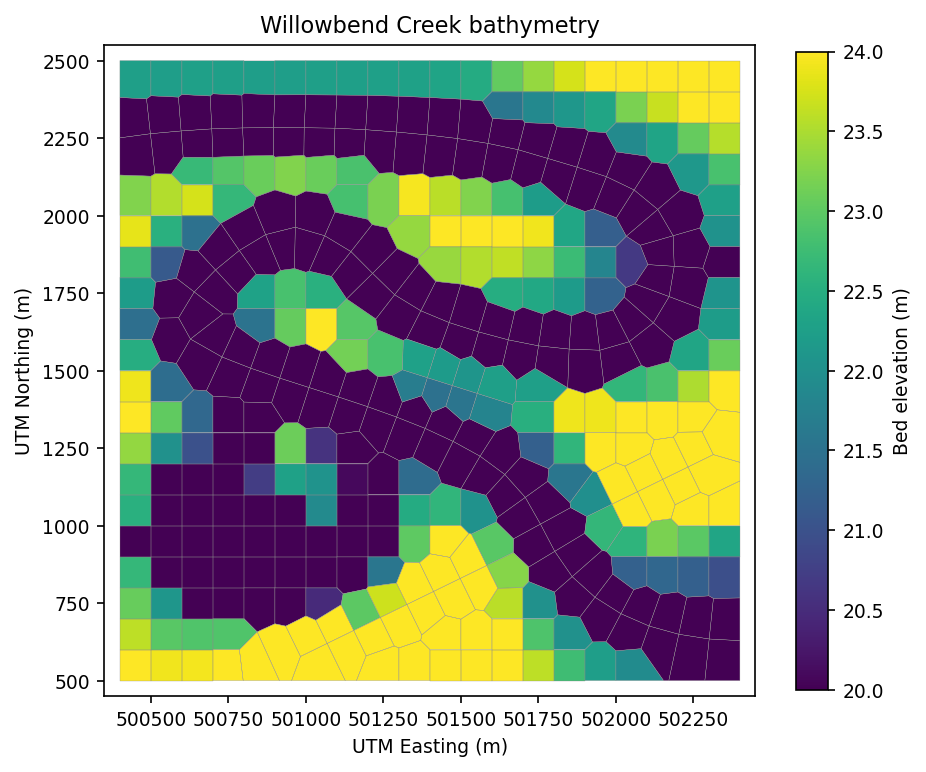

In [8]:
# lookup_elevation in HEC-RAS 2D is an (nreal, n_sample) elevation-volume
# lookup table per real cell. The minimum along axis 1 is the per-cell bed
# elevation. Real cells occupy the first nreal indices of the full-domain
# nface; ghost/boundary cells are NaN-padded to length nface.
nface_total = face_x.size
bed_elev_raw = np.asarray(registry.get("lookup_elevation").values)
if bed_elev_raw.ndim == 2:
    # HEC-RAS stores per-cell elevation-volume lookup tables of unequal length
    # that xarray pads with NaN along axis 1; nanmin collapses to the true
    # per-cell minimum bed elevation.
    bed_per_real = np.nanmin(bed_elev_raw, axis=1)
else:
    bed_per_real = bed_elev_raw

bed_elev = np.full(nface_total, np.nan)
bed_elev[: bed_per_real.size] = bed_per_real
bath_mask = np.isfinite(bed_elev) & (bed_elev > -1000.0)

fig, ax = plt.subplots(figsize=(7.0, 6.5))
sm = plot_polygons(ax, polys, face_ids, bed_elev,
                   cmap="viridis", mask=bath_mask)
cb = fig.colorbar(sm, ax=ax, shrink=0.85)
cb.set_label("Bed elevation (m)")
set_common_axis(ax, face_x, face_y)
ax.set_title("Willowbend Creek bathymetry")
fig.savefig(FIG_DIR / "bathymetry.png")
plt.show()


## 6. Figure: Boundary-condition time series

`fig:boundary-conditions` shows the prescribed thermal boundary-condition
time series at each of the four boundaries over the simulation window.
The pulsing power-plant outfall and the steady cold-water spring are the
two principal drivers of horizontal thermal heterogeneity in the domain.


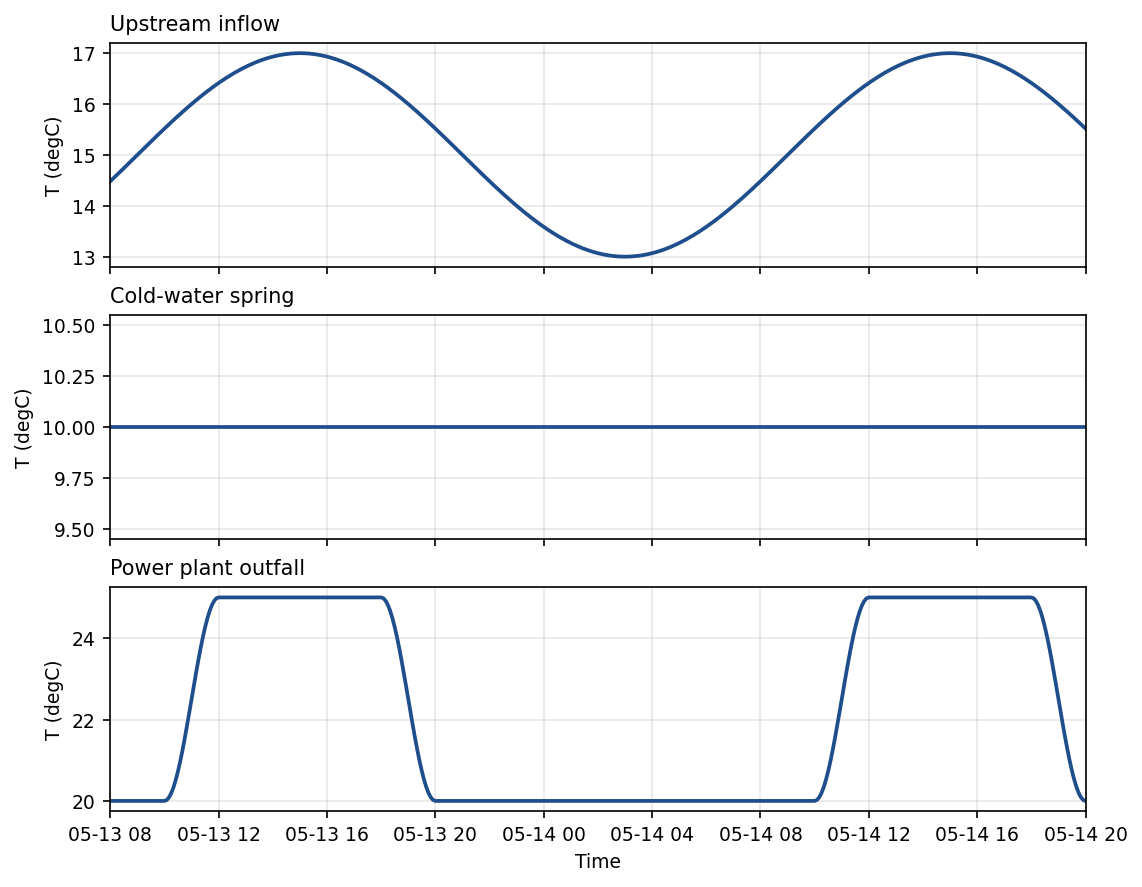

In [9]:
bc_df = pd.read_csv(sim_path / "cwr_boundary_conditions_temp.csv")
bc_df["Datetime"] = pd.to_datetime(bc_df["Datetime"])
bc_wide = bc_df.pivot(index="Datetime", columns="RAS2D_TS_Name",
                      values="water_temperature")
sim_start = pd.Timestamp(time_coord.values[0])
sim_end = pd.Timestamp(time_coord.values[-1])

# The downstream stage boundary is shown only as an inflow-reversal
# fallback in HEC-RAS and is inactive under the steady outflow in this
# case; it is omitted here to keep the figure focused on the active
# thermal drivers.
boundary_labels = {
    "US_Flow": "Upstream inflow",
    "CoriolisColdSpringCreek": "Cold-water spring",
    "PwrPlnt_Flow": "Power plant outfall",
}

fig, axes = plt.subplots(len(boundary_labels), 1, figsize=(7.5, 5.8),
                          sharex=True, constrained_layout=True)
for ax, (key, label) in zip(axes, boundary_labels.items()):
    if key in bc_wide.columns:
        series = bc_wide[key].dropna()
        ax.plot(series.index, series.values,
                linewidth=1.8, color="#1f4e8c")
    ax.set_ylabel("T (degC)", fontsize=9)
    ax.set_title(label, loc="left", fontsize=10)
    ax.set_xlim(sim_start, sim_end)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Time")
fig.savefig(FIG_DIR / "boundary_conditions.png")
plt.show()


## 7. Figure: Meteorological forcing time series

`fig:meteorology` shows the meteorological forcing applied uniformly over
the domain. Air temperature and incoming shortwave radiation are
time-varying (read from CSV); cloudiness, wind speed, atmospheric pressure,
and atmospheric vapor pressure are uniform scalars (set in `modules.yml`).


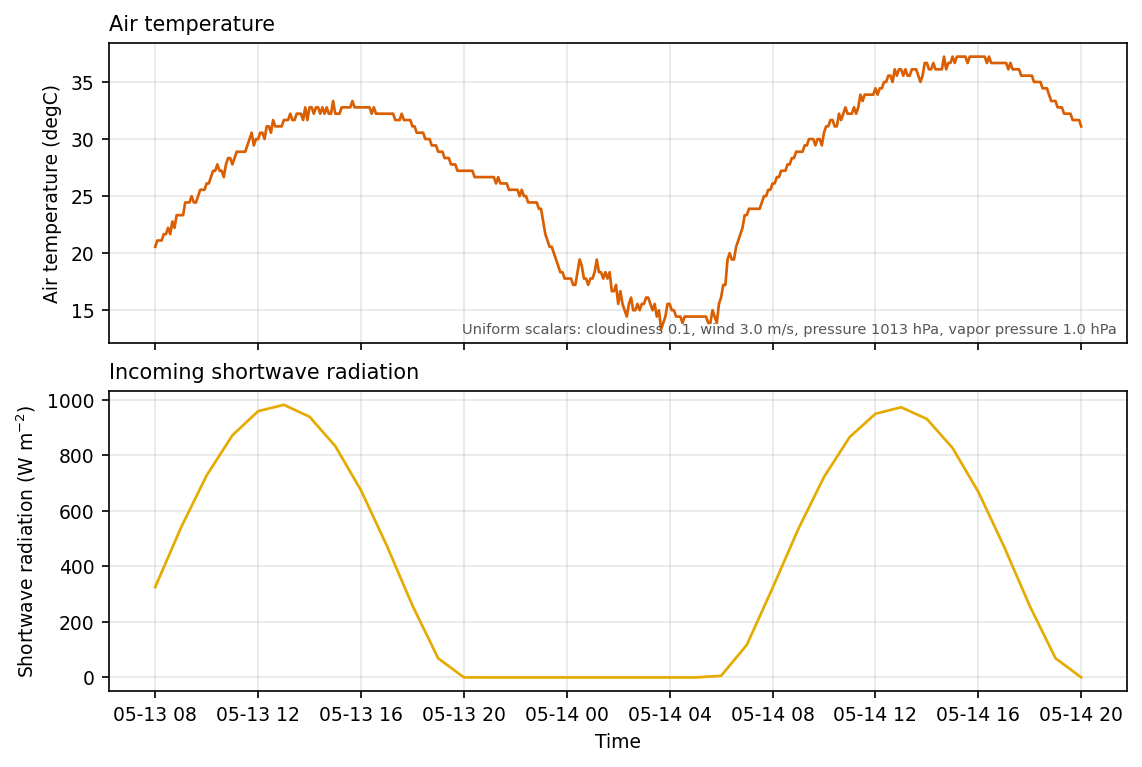

In [10]:
tair_df = pd.read_csv(sim_path / "cwr_boundary_conditions_TairC_p28.csv")
tair_df["Datetime"] = pd.to_datetime(tair_df["Datetime"])
solar_df = pd.read_csv(sim_path / "cwr_boundary_conditions_q_Solar_p28.csv")
solar_df["Datetime"] = pd.to_datetime(solar_df["Datetime"])

tair_win = tair_df[(tair_df["Datetime"] >= sim_start) & (tair_df["Datetime"] <= sim_end)]
solar_win = solar_df[(solar_df["Datetime"] >= sim_start) & (solar_df["Datetime"] <= sim_end)]

fig, axes = plt.subplots(2, 1, figsize=(7.5, 5.0),
                          sharex=True, constrained_layout=True)
axes[0].plot(tair_win["Datetime"], tair_win["TairC"],
             color="#d95f02", linewidth=1.3)
axes[0].set_ylabel("Air temperature (degC)", fontsize=9)
axes[0].set_title("Air temperature", loc="left", fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].plot(solar_win["Datetime"], solar_win["q_Solar"],
             color="#e6ab02", linewidth=1.3)
axes[1].set_ylabel("Shortwave radiation (W m$^{-2}$)", fontsize=9)
axes[1].set_title("Incoming shortwave radiation", loc="left", fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Time")

axes[0].text(0.99, 0.02,
             "Uniform scalars: cloudiness 0.1, wind 3.0 m/s, "
             "pressure 1013 hPa, vapor pressure 1.0 hPa",
             transform=axes[0].transAxes, fontsize=7, ha="right",
             va="bottom", color="#555555")

fig.savefig(FIG_DIR / "meteorology.png")
plt.show()


## 8. Figures: Hydrodynamic snapshots at start and end

`fig:depth-start`, `fig:depth-end`, `fig:velocity-start`, and
`fig:velocity-end` document the hydrodynamic state near the beginning and
end of the simulation. Water depth is computed per cell from the HEC-RAS
water-surface elevation minus the bed elevation. Velocity magnitude is
aggregated from edge-normal velocities to cell centers via
`edge_face_connectivity`. The turbo colormap highlights the wide dynamic
range from slow floodplain flow to channel thalweg and downstream
acceleration.


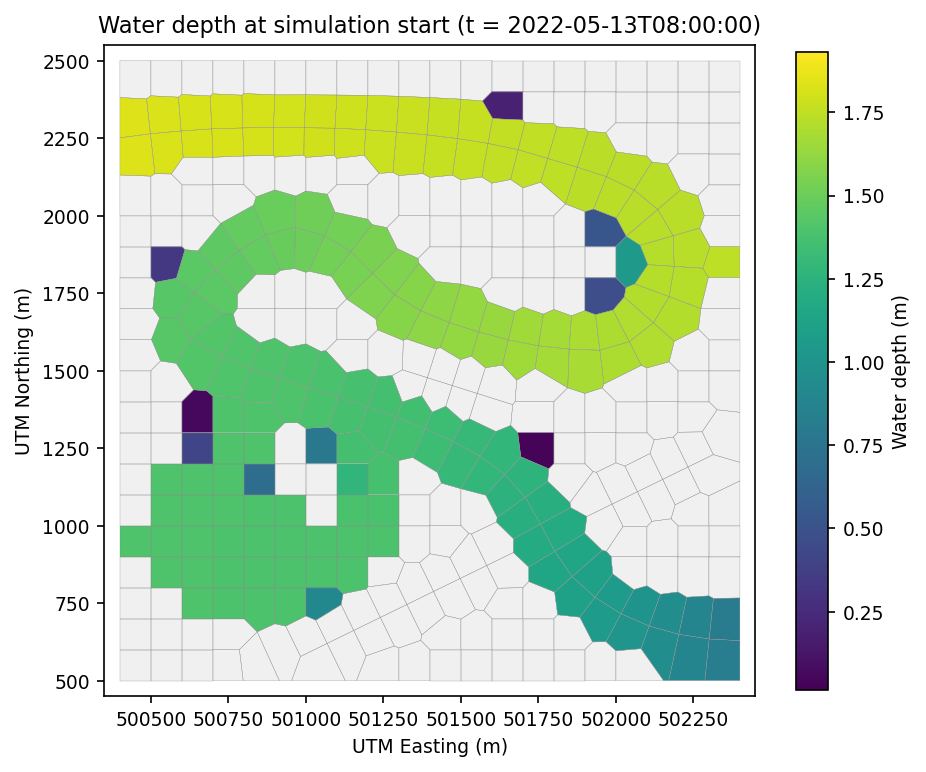

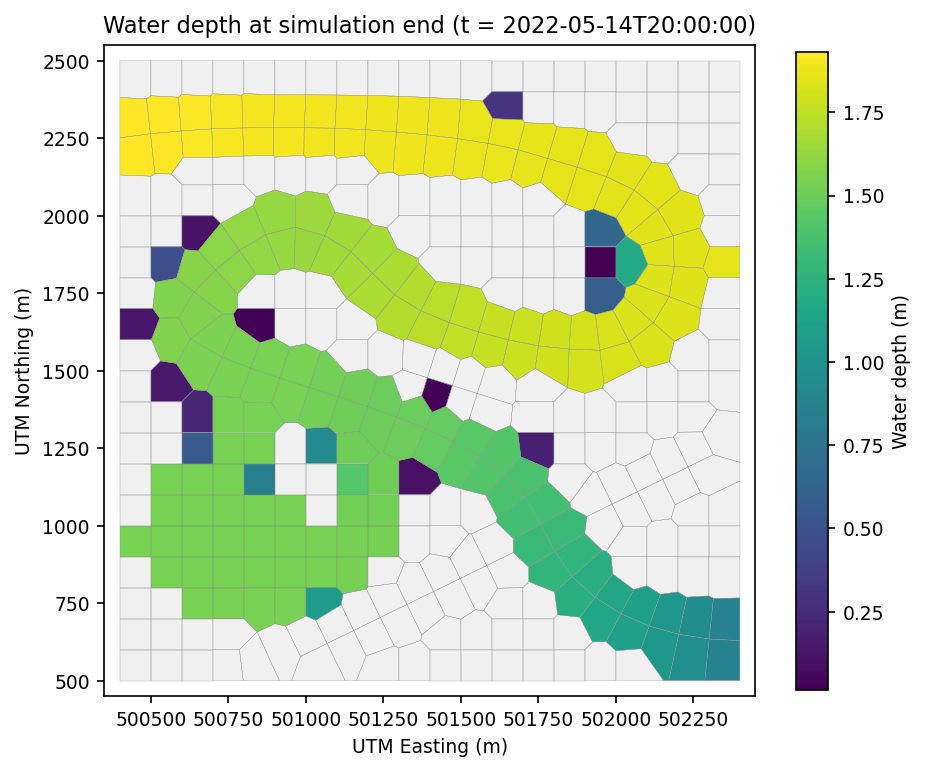

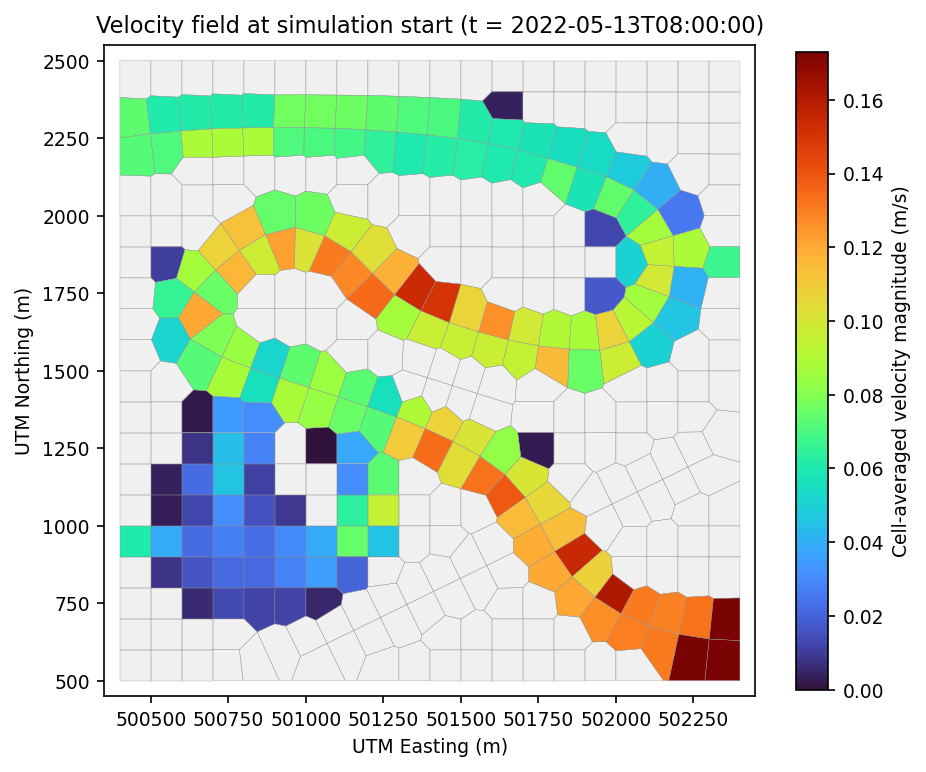

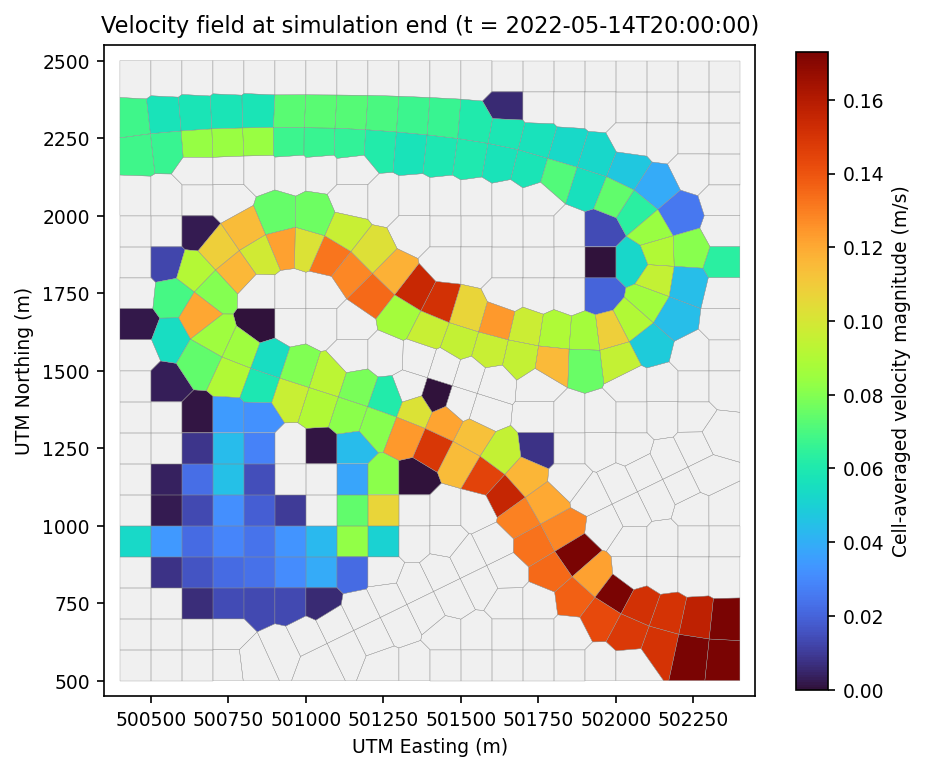

In [11]:
edge_face_conn = registry.get("edge_face_connectivity").values.astype(int)
nface = face_x.size


def _cell_velocity_at(time_idx):
    es = np.abs(registry.get("edge_velocity").isel(time=time_idx).values)
    csum = np.zeros(nface)
    ccnt = np.zeros(nface, dtype=int)
    for e in range(edge_face_conn.shape[0]):
        s = es[e]
        if not np.isfinite(s):
            continue
        for c in edge_face_conn[e]:
            if 0 <= c < nface:
                csum[c] += s
                ccnt[c] += 1
    return np.where(ccnt > 0, csum / np.maximum(ccnt, 1), 0.0)


# Depth at every time step. bed_elev is already a length-nface array with
# NaN for non-real cells (constructed in the bathymetry cell above).
wse_all = np.asarray(registry.get("water_surface_elev").values)  # (time, nface)
depth_all = wse_all - bed_elev[np.newaxis, :]

start_idx = 0
end_idx = _T_values.shape[0] - 1

# Define the wet domain purely from depth so the mask is stable across
# time. The temperature field is NaN at ghost cells after t=0, which
# would otherwise shrink the apparent domain to a handful of cells.
# A physical wet threshold (1 cm) strips cells that the HEC-RAS output
# records with depth exactly 0 -- roundoff artifacts in the floodplain
# padding that would otherwise show up as scattered dark cells outside
# the channel.
WET_THRESH = 0.01  # meters
wet_start = np.isfinite(depth_all[start_idx]) & (depth_all[start_idx] > WET_THRESH)
wet_end = np.isfinite(depth_all[end_idx]) & (depth_all[end_idx] > WET_THRESH)

# Common depth scale across start and end for fair visual comparison.
depth_vals_both = np.concatenate([
    depth_all[start_idx][wet_start],
    depth_all[end_idx][wet_end],
])
d_vmin = float(np.nanmin(depth_vals_both)) if depth_vals_both.size else 0.0
d_vmax = float(np.nanmax(depth_vals_both)) if depth_vals_both.size else 1.0

vel_start_arr = _cell_velocity_at(start_idx)
vel_end_arr = _cell_velocity_at(end_idx)
vel_vals_both = np.concatenate([vel_start_arr[wet_start], vel_end_arr[wet_end]])
v_vmax = float(np.nanquantile(vel_vals_both, 0.98)) if vel_vals_both.size else 0.5


def _snapshot(values, mask, cmap, vmin, vmax, label, title, filename):
    fig, ax = plt.subplots(figsize=(7.0, 6.5))
    sm = plot_polygons(ax, polys, face_ids, values, cmap=cmap,
                       vmin=vmin, vmax=vmax, mask=mask)
    cb = fig.colorbar(sm, ax=ax, shrink=0.85)
    cb.set_label(label)
    set_common_axis(ax, face_x, face_y)
    ax.set_title(title)
    fig.savefig(FIG_DIR / filename)
    plt.show()


start_time_str = str(time_coord.values[start_idx])[:19]
end_time_str = str(time_coord.values[end_idx])[:19]

_snapshot(depth_all[start_idx], wet_start, "viridis", d_vmin, d_vmax,
          "Water depth (m)",
          f"Water depth at simulation start (t = {start_time_str})",
          "water_depth_start.png")
_snapshot(depth_all[end_idx], wet_end, "viridis", d_vmin, d_vmax,
          "Water depth (m)",
          f"Water depth at simulation end (t = {end_time_str})",
          "water_depth_end.png")
_snapshot(vel_start_arr, wet_start, "turbo", 0.0, max(v_vmax, 0.05),
          "Cell-averaged velocity magnitude (m/s)",
          f"Velocity field at simulation start (t = {start_time_str})",
          "velocity_start.png")
_snapshot(vel_end_arr, wet_end, "turbo", 0.0, max(v_vmax, 0.05),
          "Cell-averaged velocity magnitude (m/s)",
          f"Velocity field at simulation end (t = {end_time_str})",
          "velocity_end.png")


## 6. Figure: Spatial temperature distribution

`fig:temperature-spatial` shows cell-centered water temperature at the
late-afternoon diurnal peak, demonstrating the cold-water spring plume,
the power plant thermal plume, and the oxbow lake thermal signature.


Peak index: 3600  (2022-05-14T14:00:00)


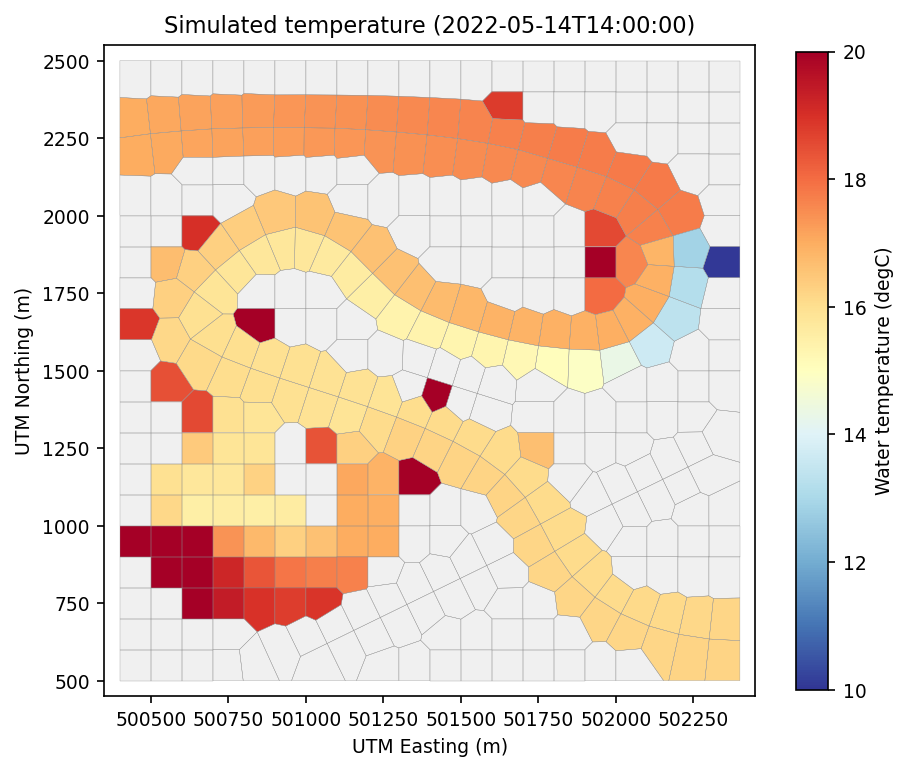

In [12]:
# Fix peak index at ~30 hours in (day-2 afternoon for the arid diurnal cycle).
peak_index = min(_T_values.shape[0] - 1, int(30 * 3600 / 30))
peak_time_str = str(time_coord.values[peak_index])[:19]
print(f"Peak index: {peak_index}  ({peak_time_str})")

temps = _T_values[peak_index]
# Mask dry/ghost cells (T <= 5 degC collapse) so they do not pollute the colormap.
wet_mask = temps > 5.0

fig, ax = plt.subplots(figsize=(7.0, 6.5))
sm = plot_polygons(ax, polys, face_ids, temps,
                   cmap="RdYlBu_r", vmin=10, vmax=20, mask=wet_mask)
cb = fig.colorbar(sm, ax=ax, shrink=0.85)
cb.set_label("Water temperature (degC)")
set_common_axis(ax, face_x, face_y)
ax.set_title(f"Simulated temperature ({peak_time_str})")
fig.savefig(FIG_DIR / "temperature_spatial.png")
plt.show()


## 6b. Figure: Spatial temperature at the diurnal minimum

`fig:temperature-spatial-min` is the pre-dawn counterpart to
`fig:temperature-spatial`. The time index is chosen as the output
record with the lowest domain-mean water temperature, which lands in
the pre-dawn hours of the second simulated day. Plotting this snapshot
alongside the diurnal-peak map makes the magnitude of the diurnal cycle
and the persistence of the thermal-plume and cold-spring signatures
directly visible.


/var/folders/xd/gqx9m71n4fx9z83607c2cwl80000gn/T/ipykernel_15955/1816886983.py:7: RuntimeWarning: Mean of empty slice
  _mean_over_wet = np.nanmean(_T_valid[:, _wet_ever], axis=1)


Diurnal-minimum index: 2646  (2022-05-14T06:03:00)  mean T over wet cells = 11.55 degC


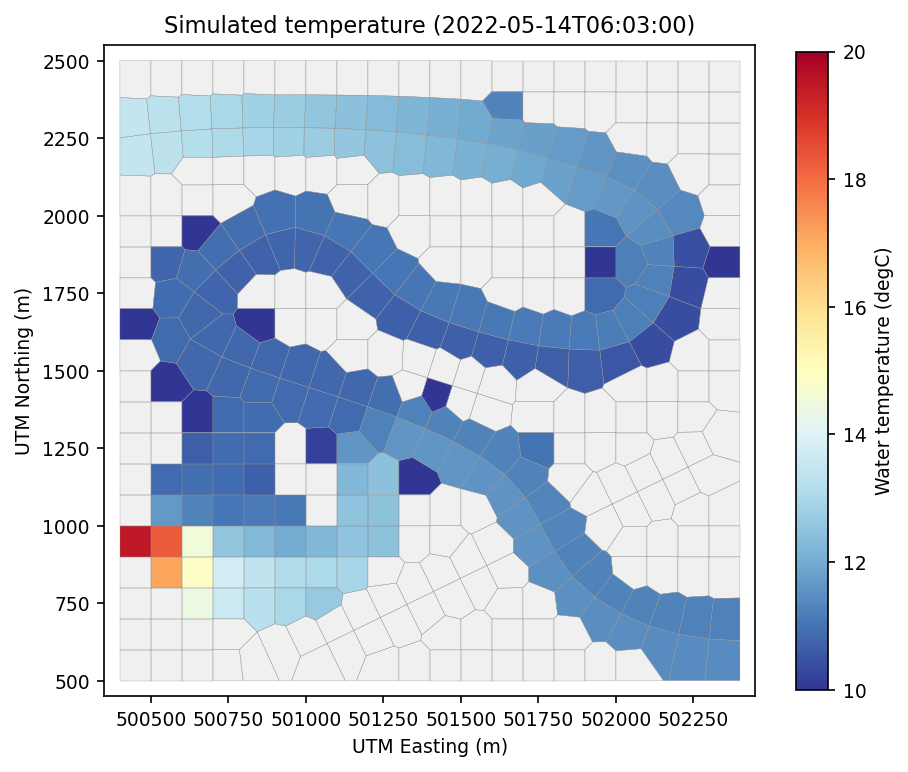

In [13]:
# Domain-mean water temperature over wet cells; the minimum over time
# is the diurnal-minimum snapshot. The ever-wet mask (set later in the
# notebook for the persistence and amplitude figures) is reconstructed
# locally so this cell is self-contained.
_wet_ever = np.any(np.isfinite(depth_all) & (depth_all > WET_THRESH), axis=0)
_T_valid = np.where(np.isfinite(_T_values), _T_values, np.nan)
_mean_over_wet = np.nanmean(_T_valid[:, _wet_ever], axis=1)
min_index_spatial = int(np.nanargmin(_mean_over_wet))
min_time_str_spatial = str(time_coord.values[min_index_spatial])[:19]
print(f"Diurnal-minimum index: {min_index_spatial}  ({min_time_str_spatial})  "
      f"mean T over wet cells = {_mean_over_wet[min_index_spatial]:.2f} degC")

temps_min = _T_values[min_index_spatial]
wet_mask_min = temps_min > 5.0

fig, ax = plt.subplots(figsize=(7.0, 6.5))
sm = plot_polygons(ax, polys, face_ids, temps_min,
                   cmap="RdYlBu_r", vmin=10, vmax=20, mask=wet_mask_min)
cb = fig.colorbar(sm, ax=ax, shrink=0.85)
cb.set_label("Water temperature (degC)")
set_common_axis(ax, face_x, face_y)
ax.set_title(f"Simulated temperature ({min_time_str_spatial})")
fig.savefig(FIG_DIR / "temperature_spatial_min.png")
plt.show()


## 6c. Figure: Time-averaged temperature map

`fig:temperature-spatial-mean` shows, for every ever-wet cell, the mean
simulated temperature over the 36-hour simulation window. Averaging
removes the diurnal swing captured by the peak and minimum snapshots
and isolates the persistent thermal structure of the domain: cells that
are systematically cool (the cold-water spring corridor and its
downstream plume), cells that are systematically warm (the power-plant
outfall and its downstream plume), and the intermediate background
established by the upstream inflow.


/var/folders/xd/gqx9m71n4fx9z83607c2cwl80000gn/T/ipykernel_15955/2585711287.py:4: RuntimeWarning: Mean of empty slice
  mean_temp = np.nanmean(_T_valid, axis=0)


Time-averaged temperature stats (ever-wet cells): min=10.05 degC mean=15.45 degC max=22.06 degC


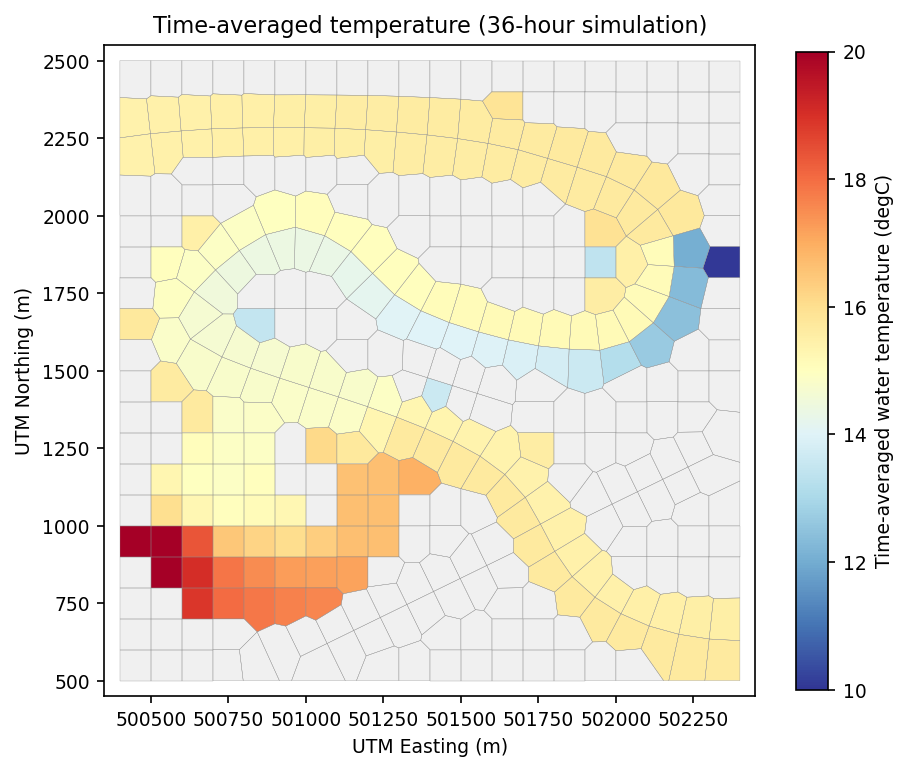

In [14]:
# Per-cell time-mean temperature over the ever-wet domain, plotted on
# the same 10--20 degC color scale as fig:temperature-spatial and
# fig:temperature-spatial-min for direct visual comparison.
mean_temp = np.nanmean(_T_valid, axis=0)
mean_mask = _wet_ever & np.isfinite(mean_temp)

print(f"Time-averaged temperature stats (ever-wet cells): "
      f"min={np.nanmin(mean_temp[mean_mask]):.2f} degC "
      f"mean={np.nanmean(mean_temp[mean_mask]):.2f} degC "
      f"max={np.nanmax(mean_temp[mean_mask]):.2f} degC")

fig, ax = plt.subplots(figsize=(7.0, 6.5))
sm = plot_polygons(ax, polys, face_ids, mean_temp,
                   cmap="RdYlBu_r", vmin=10, vmax=20, mask=mean_mask)
cb = fig.colorbar(sm, ax=ax, shrink=0.85)
cb.set_label("Time-averaged water temperature (degC)")
set_common_axis(ax, face_x, face_y)
ax.set_title("Time-averaged temperature (36-hour simulation)")
fig.savefig(FIG_DIR / "temperature_spatial_mean.png")
plt.show()


## 7. Figure: Temperature timeseries

`fig:temperature-timeseries` tracks water temperature at six representative
cells that sample the upstream reach, spring confluence, power plant
mixing zone, and downstream recovery. The coupled (TSM-driven) and
transport-only temperatures are overlaid to isolate the contribution of
atmospheric heat exchange from boundary mixing.


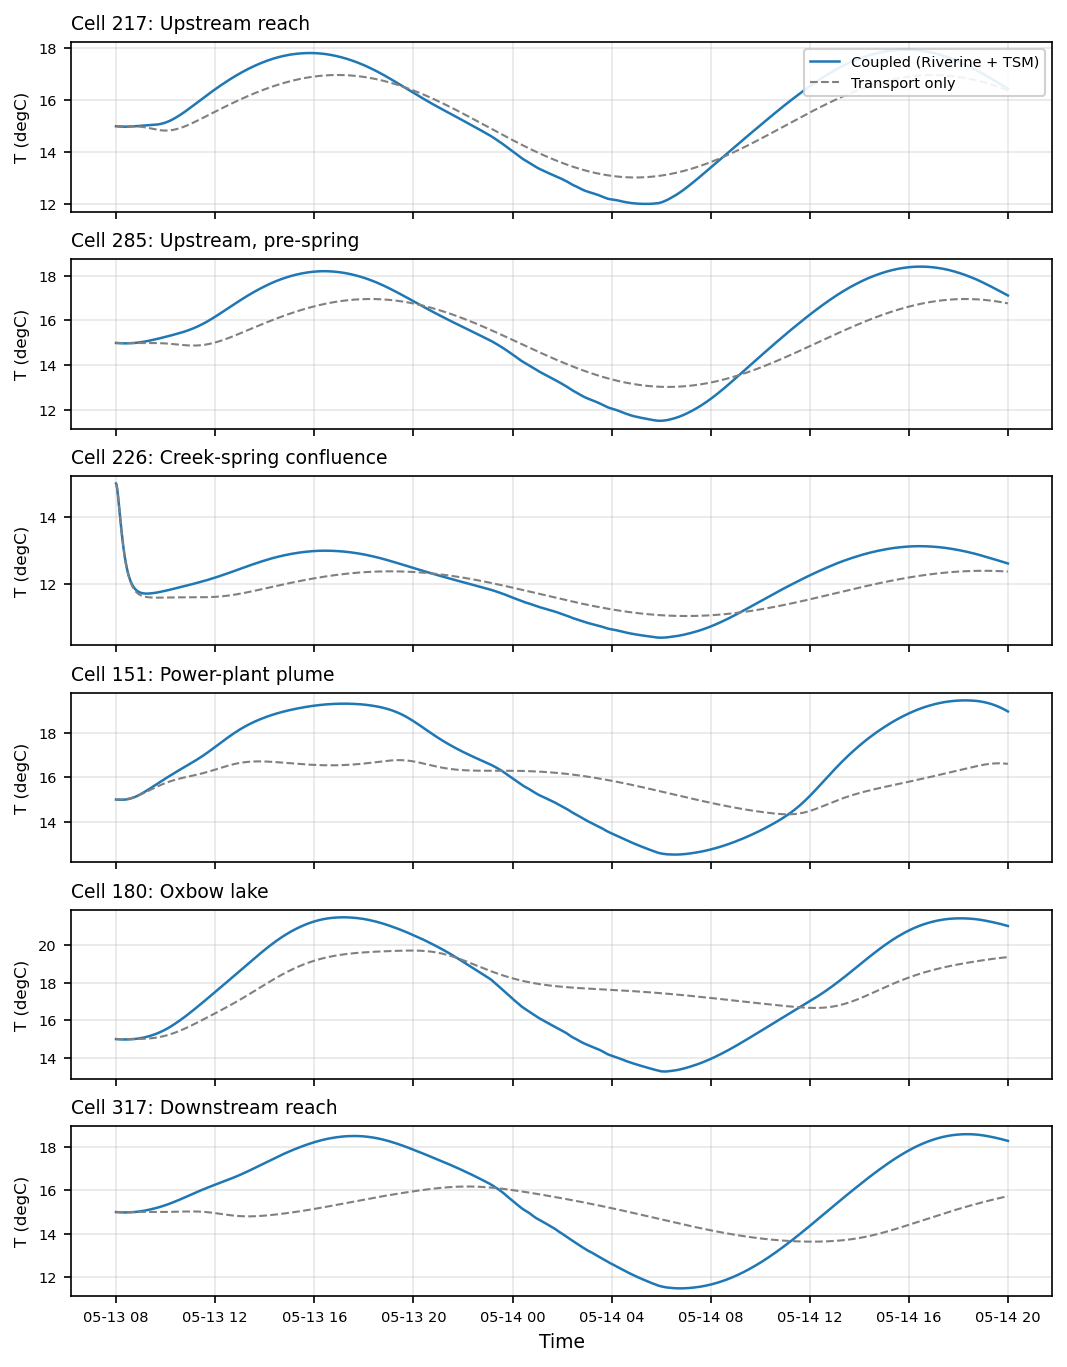

In [15]:
representative_cells = {
    217: "Upstream reach",
    285: "Upstream, pre-spring",
    226: "Creek-spring confluence",
    151: "Power-plant plume",
    180: "Oxbow lake",
    317: "Downstream reach",
}

fig, axes = plt.subplots(len(representative_cells), 1, figsize=(7.0, 9.0),
                          sharex=True, constrained_layout=True)

for ax, (cell, label) in zip(axes, representative_cells.items()):
    t_coupled = water_temperature.isel(nface=cell).values
    t_transport = water_temperature_transport.isel(nface=cell).values
    times = pd.to_datetime(time_coord.values)
    ax.plot(times, t_coupled, linewidth=1.2, label="Coupled (Riverine + TSM)")
    ax.plot(times, t_transport, linewidth=1.0, linestyle="--",
            color="gray", label="Transport only")
    ax.set_ylabel("T (degC)", fontsize=8)
    ax.set_title(f"Cell {cell}: {label}", fontsize=9, loc="left")
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.legend(loc="upper right", fontsize=7, framealpha=0.9)

axes[-1].set_xlabel("Time")
fig.savefig(FIG_DIR / "temperature_timeseries.png")
plt.show()


## 8. Figure: Thermal refugia map

`fig:refugia-map` identifies cells whose simulated temperature remains
below a refugia threshold during the diurnal peak. The threshold is
defined here as the 25th percentile of the spatial temperature
distribution at the peak time, which selects the persistently cooler
portion of the domain. Users should adjust this threshold to reflect the
species-specific definition appropriate to their application.


Refugia threshold (absolute): 14.00 degC
Refugia cells: 5 of 179 active (2.8%)


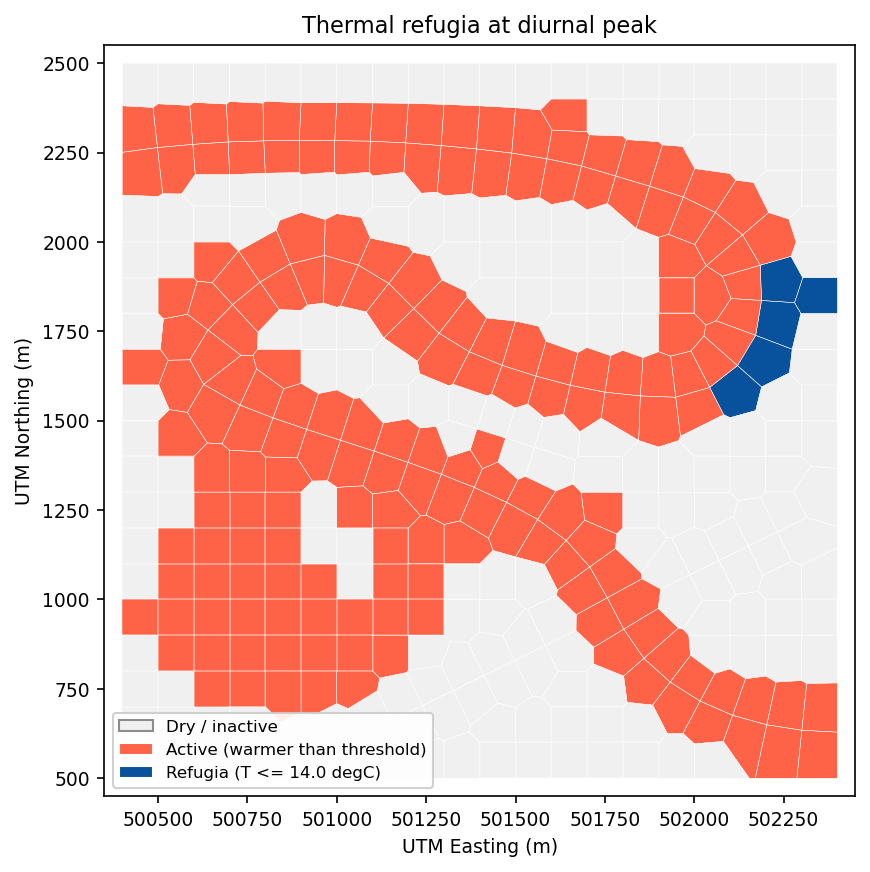

In [16]:
# Refugia threshold: 14 degC. Chosen from the published cold-water-salmonid
# thermal-preference literature (see methodology in Section 3.4.1 of the
# report); captures the spring-influenced plume while excluding the
# atmospherically warmed upstream reach.
peak_temps = _T_values[peak_index]
refugia_threshold = 14.0
active_mask = peak_temps > 5.0
refugia_mask = active_mask & (peak_temps <= refugia_threshold)
print(f"Refugia threshold (absolute): {refugia_threshold:.2f} degC")
print(f"Refugia cells: {int(refugia_mask.sum())} of {int(active_mask.sum())} active "
      f"({100 * refugia_mask.sum() / max(active_mask.sum(), 1):.1f}%)")

# Categorical 2-class field over active cells: 1 = active non-refugia, 2 = refugia.
# Dry/inactive cells are suppressed into the dry-cell style via the mask.
category = np.full(peak_temps.shape[0], 1.0)
category[refugia_mask] = 2.0
cat_cmap = ListedColormap(["tomato", "#08519c"])
cat_norm = BoundaryNorm([0.5, 1.5, 2.5], cat_cmap.N)

fig, ax = plt.subplots(figsize=(7.0, 6.5))
plot_polygons(ax, polys, face_ids, category,
              cmap=cat_cmap, norm=cat_norm, mask=active_mask,
              show_edges=True, edgecolor="white", lw=0.2)

legend_entries = [
    mpatches.Patch(facecolor=DRY_FILL, edgecolor=DRY_EDGE, label="Dry / inactive"),
    mpatches.Patch(facecolor="tomato", edgecolor="white",
                   label="Active (warmer than threshold)"),
    mpatches.Patch(facecolor="#08519c", edgecolor="white",
                   label=f"Refugia (T <= {refugia_threshold:.1f} degC)"),
]
ax.legend(handles=legend_entries, loc="lower left", fontsize=8, framealpha=0.9)
set_common_axis(ax, face_x, face_y)
ax.set_title("Thermal refugia at diurnal peak")
fig.savefig(FIG_DIR / "refugia_map.png")
plt.show()


## 8c. Figure: Refugia persistence map

`fig:refugia-persistence` shows, for every wet cell, the fraction of the
simulation window during which that cell remained at or below the
\SI{14}{\degreeCelsius} refugia threshold. Cells shaded near
\SI{100}{\percent} are persistent refugia supported by continuous
cold-water inputs (e.g., the cold-water spring); cells shaded near
\SI{0}{\percent} are warm zones that never qualify. Intermediate values
mark transient refugia that flip on and off with the diurnal cycle.


Refugia persistence stats (ever-wet cells): min=0.0% mean=29.1% max=99.9%


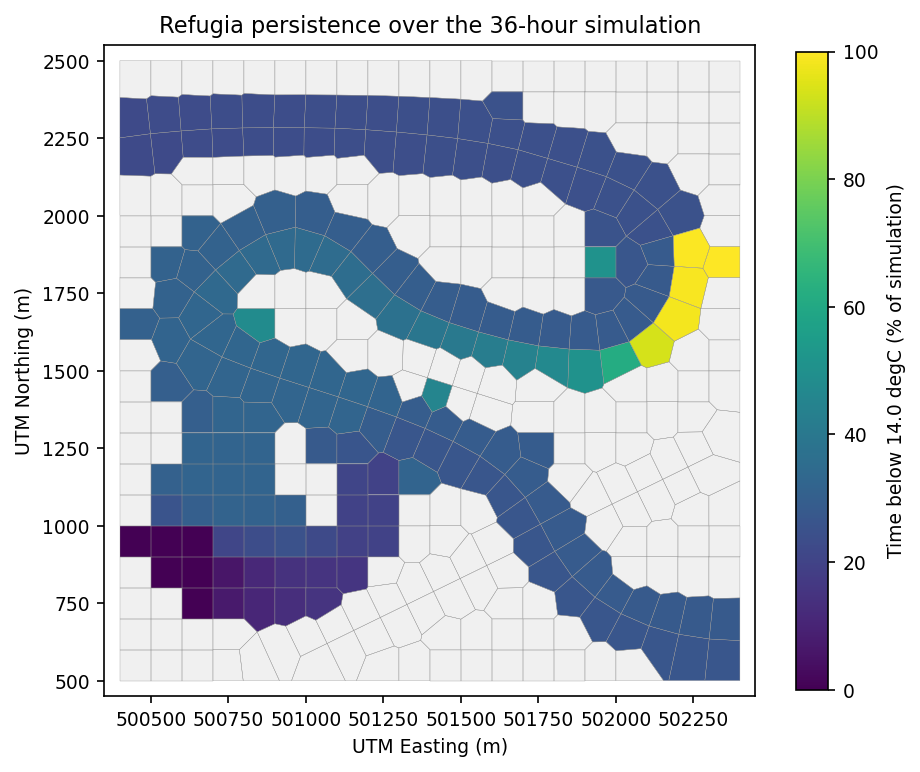

In [17]:
# Per-cell fraction (0-100%) of time steps at or below the refugia threshold.
# The "ever wet" mask is built from the depth field rather than the
# temperature field, so ghost / non-real cells (whose T is NaN after
# t=0 but may carry a stale initial value) are excluded cleanly and
# shown in the dry-cell style, matching the depth and velocity figures.
ever_wet = np.any(np.isfinite(depth_all) & (depth_all > WET_THRESH), axis=0)
time_below = np.sum((_T_values <= refugia_threshold)
                    & np.isfinite(_T_values), axis=0)
time_valid = np.sum(np.isfinite(_T_values), axis=0)
persistence = np.zeros(_T_values.shape[1])
valid = (time_valid > 0) & ever_wet
persistence[valid] = 100.0 * time_below[valid] / time_valid[valid]

print(f"Refugia persistence stats (ever-wet cells): "
      f"min={persistence[valid].min():.1f}% "
      f"mean={persistence[valid].mean():.1f}% "
      f"max={persistence[valid].max():.1f}%")

fig, ax = plt.subplots(figsize=(7.0, 6.5))
sm = plot_polygons(ax, polys, face_ids, persistence,
                   cmap="viridis", vmin=0.0, vmax=100.0, mask=ever_wet)
cb = fig.colorbar(sm, ax=ax, shrink=0.85)
cb.set_label(f"Time below {refugia_threshold:.1f} degC (% of simulation)")
set_common_axis(ax, face_x, face_y)
ax.set_title("Refugia persistence over the 36-hour simulation")
fig.savefig(FIG_DIR / "refugia_persistence.png")
plt.show()


## 8d. Figure: Diurnal temperature amplitude map

`fig:diurnal-amplitude` shows the per-cell range between the maximum
and minimum simulated temperature over the 36-hour simulation window.
Large amplitudes indicate cells whose temperature is strongly driven by
atmospheric forcing (shallow water, quiescent flow, long residence time),
while small amplitudes indicate cells buffered by cold-water inputs or
by rapid through-flow.


/var/folders/xd/gqx9m71n4fx9z83607c2cwl80000gn/T/ipykernel_15955/4114533567.py:4: RuntimeWarning: All-NaN slice encountered
  cell_max = np.nanmax(T_masked, axis=0)
/var/folders/xd/gqx9m71n4fx9z83607c2cwl80000gn/T/ipykernel_15955/4114533567.py:5: RuntimeWarning: All-NaN slice encountered
  cell_min = np.nanmin(T_masked, axis=0)


Diurnal amplitude stats (ever-wet cells): min=4.16 degC mean=7.22 degC max=25.95 degC


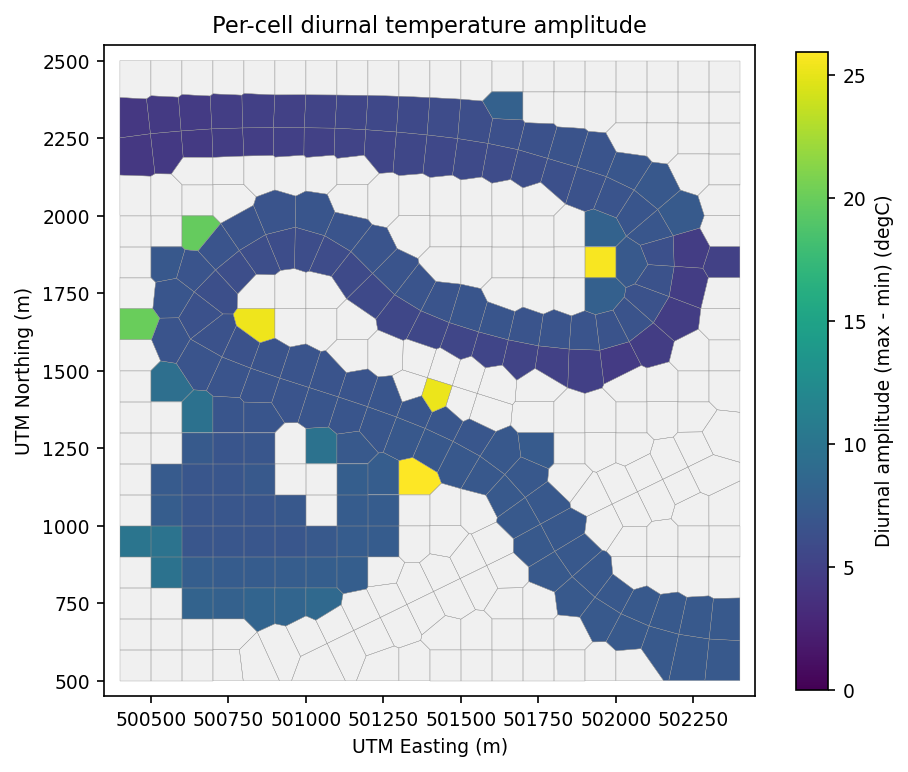

In [18]:
# Per-cell (max - min) over all time steps, restricted to the
# ever-wet domain (depth-based mask, matching the other plots).
T_masked = np.where(np.isfinite(_T_values), _T_values, np.nan)
cell_max = np.nanmax(T_masked, axis=0)
cell_min = np.nanmin(T_masked, axis=0)
amplitude = cell_max - cell_min
amp_mask = ever_wet & np.isfinite(amplitude)

print(f"Diurnal amplitude stats (ever-wet cells): "
      f"min={np.nanmin(amplitude[amp_mask]):.2f} degC "
      f"mean={np.nanmean(amplitude[amp_mask]):.2f} degC "
      f"max={np.nanmax(amplitude[amp_mask]):.2f} degC")

fig, ax = plt.subplots(figsize=(7.0, 6.5))
sm = plot_polygons(ax, polys, face_ids, amplitude,
                   cmap="viridis", vmin=0.0,
                   vmax=float(np.nanmax(amplitude[amp_mask])),
                   mask=amp_mask)
cb = fig.colorbar(sm, ax=ax, shrink=0.85)
cb.set_label("Diurnal amplitude (max - min) (degC)")
set_common_axis(ax, face_x, face_y)
ax.set_title("Per-cell diurnal temperature amplitude")
fig.savefig(FIG_DIR / "diurnal_amplitude.png")
plt.show()


## 9. Figure: Refugia temporal evolution

`fig:refugia-temporal` tracks the instantaneous refugia area fraction
over the simulation window, showing how the thermal refugia footprint
expands and contracts with the diurnal cycle.


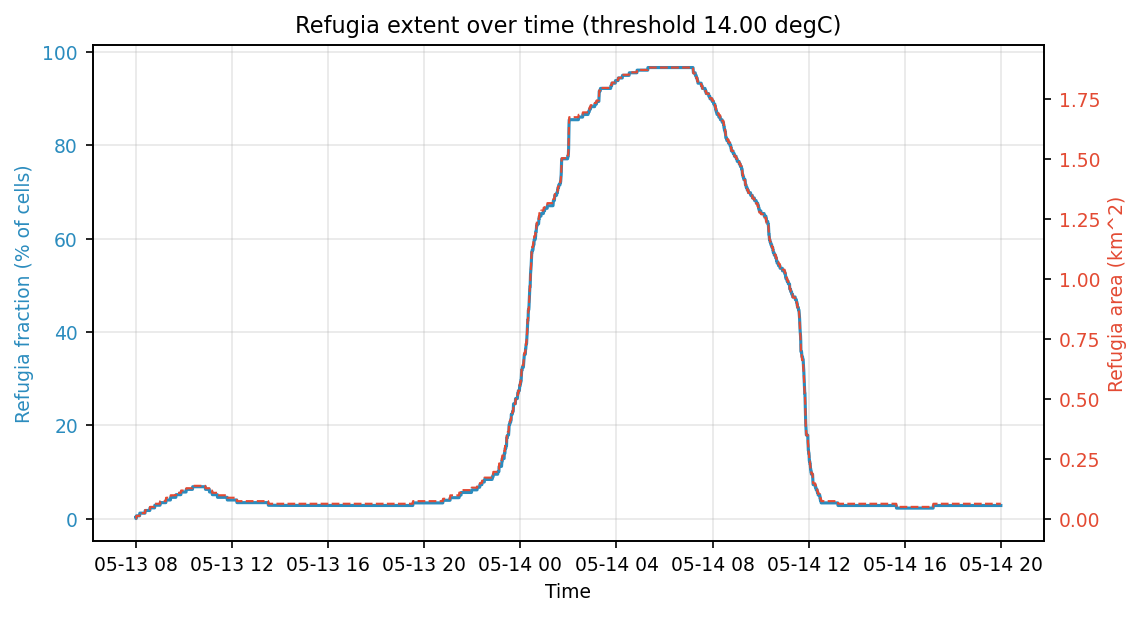

In [19]:
try:
    cell_areas = registry.get("faces_surface_area").values
except (KeyError, ValueError):
    cell_areas = np.ones_like(face_x.values)

temperature_values = _T_values
refugia_fraction = np.empty(temperature_values.shape[0])
refugia_area_m2 = np.empty_like(refugia_fraction)

for i in range(temperature_values.shape[0]):
    row = temperature_values[i]
    active_i = row > 5.0
    refugia_i = active_i & (row <= refugia_threshold)
    denom = int(active_i.sum())
    refugia_fraction[i] = refugia_i.sum() / denom if denom > 0 else 0.0
    refugia_area_m2[i] = cell_areas[refugia_i].sum()

fig, ax1 = plt.subplots(figsize=(7.5, 4.0), constrained_layout=True)
times = pd.to_datetime(time_coord.values)
# Drop the final sample: the solver sometimes writes a partial end-of-run
# frame that produces a one-step artifact in the fraction trace.
t_plot = times[:-1]
frac_plot = 100 * refugia_fraction[:-1]
area_plot = refugia_area_m2[:-1] / 1e6
ax1.plot(t_plot, frac_plot, color="#2b8cbe", linewidth=1.5,
         label="Refugia cell fraction (%)")
ax1.set_ylabel("Refugia fraction (% of cells)", color="#2b8cbe")
ax1.tick_params(axis="y", labelcolor="#2b8cbe")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(t_plot, area_plot, color="#e34a33", linewidth=1.0,
         linestyle="--", label="Refugia area (km^2)")
ax2.set_ylabel("Refugia area (km^2)", color="#e34a33")
ax2.tick_params(axis="y", labelcolor="#e34a33")

ax1.set_xlabel("Time")
ax1.set_title(f"Refugia extent over time (threshold {refugia_threshold:.2f} degC)")
fig.savefig(FIG_DIR / "refugia_temporal.png")
plt.show()


## 10. Interactive map (optional)

Uses the ClearWater-Riverine `RiverinePlotter` to render the same
temperature field as an interactive HoloViews dynamic map. This is
useful for inspection during analysis but is not used to generate
publication figures.


In [20]:
plotter = RiverinePlotter(registry=registry, crs="EPSG:26916")
plotter.dynamic_plot(constituent_name="water_temperature")


/opt/homebrew/Caskroom/miniconda/base/envs/clearwater/lib/python3.13/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/homebrew/Caskroom/miniconda/base/envs/clearwater/lib/python3.13/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/homebrew/Caskroom/miniconda/base/envs/clearwater/lib/python3.13/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


/opt/homebrew/Caskroom/miniconda/base/envs/clearwater/lib/python3.13/site-packages/shapely/constructive.py:180: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


:DynamicMap   [datetime]
   :Overlay
      .Polygons.I :Polygons   [Longitude,Latitude]   (water_temperature,nface)
      .WMTS.I     :WMTS   [Longitude,Latitude]

## 11. Climate-scenarios scaffold (optional)

`fig:climate-scenarios` in the report requires multiple runs of the
coupled model with perturbed meteorological forcing (for example, plus
3 degC uniform air-temperature offset, or increased solar radiation).
The scaffold below shows how to spin up a perturbed run by editing the
meteorological CSVs into a separate `data/willowbend_creek_hot/`
directory and pointing a new `modules.yml` at it. This block is
intentionally not executed by default.


In [21]:
# Example pattern (uncomment and adapt when scenario inputs are defined):
#
# hot_path = Path.cwd() / "data" / "willowbend_creek_hot"
# hot_config_path = hot_path / "modules.yml"
# hot_model = init_from_file(hot_config_path)
# hot_model.run()
# hot_registry = hot_model._Model__registry
# hot_temperature = hot_registry.get("water_temperature")
#
# Compare baseline vs perturbed at the diurnal peak:
# fig, ax = plt.subplots(figsize=(7, 4))
# ax.plot(times, water_temperature.mean("nface"), label="Baseline")
# ax.plot(times, hot_temperature.mean("nface"), label="Air +3 degC")
# ax.set_ylabel("Domain-mean T (degC)")
# ax.legend()
# fig.savefig(FIG_DIR / "climate_scenarios.png")


## Output

All six PNG figures are saved to `notebooks/figures/` and named to match
the `\label` keys used in the report. Copy or symlink them into
`latex/src/images/` to make the report's figure references resolve.
